## Exploratory Data Analysis (EDA)

### Objective
This notebook explores the structure and distribution of procurement approval workflow data.

The goal is to understand:
- overall turnaround behavior
- variability across request types and priorities
- differences across departments and vendors
- initial indicators of delay patterns

This forms the foundation for bottleneck analysis and predictive modeling.

In [4]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent 

FINAL_DIR = BASE_DIR / "data" / "final"

stage_df = pd.read_csv(FINAL_DIR / "final_stage_level.csv")
request_df = pd.read_csv(FINAL_DIR / "final_request_level.csv")

print("Stage-level shape:", stage_df.shape)
print("Request-level shape:", request_df.shape)

Stage-level shape: (28472, 21)
Request-level shape: (5000, 22)


### Dataset Overview

In [5]:
stage_df.head()

,Request_ID,Stage,Stage_Order,Role,Department_Stage,Department_Requesting,Request_Type,Priority,Vendor_Type,Request_Amount,...,SLA_Hours,System_Load,Start_Time,End_Time,Processing_Time,Waiting_Time,Total_Stage_Time,Rework_Flag,Is_High_Value_Request,Is_High_Complexity
0,R00001,Manager Approval,1,Manager,Management,Operations,IT Purchase,Low,Internal,122958,...,191.4,0.950714,2025-06-29 15:04:12,2025-06-30 09:00:00,16.45,6.07,22.52,0,0,0
1,R00001,Rework to Manager Approval,1,Manager,Management,Operations,IT Purchase,Low,Internal,122958,...,191.4,0.950714,2025-06-30 13:00:00,2025-06-30 13:00:00,0.00,4.00,4.00,1,0,0
2,R00001,Manager Approval,1,Manager,Management,Operations,IT Purchase,Low,Internal,122958,...,191.4,0.950714,2025-06-30 15:01:12,2025-07-01 09:00:00,16.86,2.02,18.88,0,0,0
3,R00001,Finance Approval,2,Finance Officer,Finance,Operations,IT Purchase,Low,Internal,122958,...,191.4,0.950714,2025-07-01 14:03:36,2025-07-03 13:54:00,47.84,5.06,52.90,0,0,0
4,R00001,Rework to Manager Approval,2,Finance Officer,Finance,Operations,IT Purchase,Low,Internal,122958,...,191.4,0.950714,2025-07-03 17:54:00,2025-07-03 17:54:00,0.00,4.00,4.00,1,0,0


In [6]:
request_df.head()

,Request_ID,Request_Start,Request_End,Total_Processing,Total_Waiting,SLA_Hours,Request_Type,Priority,Department_Requesting,Vendor_Type,...,System_Load,Num_Stages,Total_TAT,Delay_Ratio,SLA_Breach_Hours,Delayed_Flag,Is_High_Value_Request,Is_High_Complexity,Bottleneck_Stage,Max_Stage_Delay
0,R00001,2025-06-29 15:04:12,2025-07-10 09:00:00,172.34,40.88,191.4,IT Purchase,Low,Operations,Internal,...,0.950714,9,257.93,1.347597,66.53,1,0,0,Finance Approval,58.42
1,R00002,2025-01-08 11:30:00,2025-01-12 09:00:00,48.96,10.62,140.4,IT Purchase,High,Admin,Internal,...,0.034389,4,93.50,0.665954,0.00,0,0,0,Procurement Review,25.54
2,R00003,2025-07-07 10:52:48,2025-07-12 17:58:12,98.21,14.60,217.8,Equipment,Low,IT,Internal,...,0.542696,4,127.09,0.583517,0.00,0,0,0,Finance Approval,51.92
3,R00004,2025-07-12 14:00:36,2025-07-18 09:00:00,89.70,17.95,145.2,Office Supplies,Low,Admin,Internal,...,0.382927,4,138.99,0.957231,0.00,0,0,0,Procurement Review,40.89
4,R00005,2025-03-12 11:22:12,2025-03-17 15:14:24,86.16,22.06,102.6,Office Supplies,High,Admin,External,...,0.289751,7,123.87,1.207310,21.27,1,0,0,Finance Approval,24.26


### Data Quality Check

In [7]:
print("Missing values (stage):")
print(stage_df.isnull().sum())

print("\nMissing values (request):")
print(request_df.isnull().sum())

print("\nDuplicates (stage):", stage_df.duplicated().sum())
print("Duplicates (request):", request_df.duplicated().sum())

Missing values (stage):
Request_ID               0
Stage                    0
Stage_Order              0
Role                     0
Department_Stage         0
Department_Requesting    0
Request_Type             0
Priority                 0
Vendor_Type              0
Request_Amount           0
Complexity_Score         0
SLA_Hours                0
System_Load              0
Start_Time               0
End_Time                 0
Processing_Time          0
Waiting_Time             0
Total_Stage_Time         0
Rework_Flag              0
Is_High_Value_Request    0
Is_High_Complexity       0
dtype: int64

Missing values (request):
Request_ID               0
Request_Start            0
Request_End              0
Total_Processing         0
Total_Waiting            0
SLA_Hours                0
Request_Type             0
Priority                 0
Department_Requesting    0
Vendor_Type              0
Request_Amount           0
Complexity_Score         0
System_Load              0
Num_Stages        

### Summary Statistics

In [8]:
request_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Processing,5000.0,112.684074,53.526071,33.440000,75.790000,97.510000,133.452500,406.410000
Total_Waiting,5000.0,20.208540,10.717453,3.640000,12.610000,16.710000,25.120000,69.320000
SLA_Hours,5000.0,187.861440,50.350965,102.600000,145.200000,191.400000,232.200000,283.800000
Request_Amount,5000.0,125988.523800,72168.639075,1059.000000,63994.500000,128005.000000,189066.250000,249964.000000
Complexity_Score,5000.0,3.097600,1.221463,1.000000,2.000000,3.000000,4.000000,5.000000
System_Load,5000.0,0.493954,0.288899,0.000008,0.243731,0.495033,0.742651,0.999316
Num_Stages,5000.0,5.694400,2.593290,3.000000,4.000000,4.000000,7.000000,15.000000
Total_TAT,5000.0,168.569434,76.380161,46.770000,116.920000,141.305000,197.800000,550.300000
Delay_Ratio,5000.0,0.939150,0.441598,0.320413,0.617908,0.814842,1.108852,3.982137
SLA_Breach_Hours,5000.0,23.556542,49.708545,0.000000,0.000000,0.000000,19.790000,373.960000


### Turnaround Time Distribution

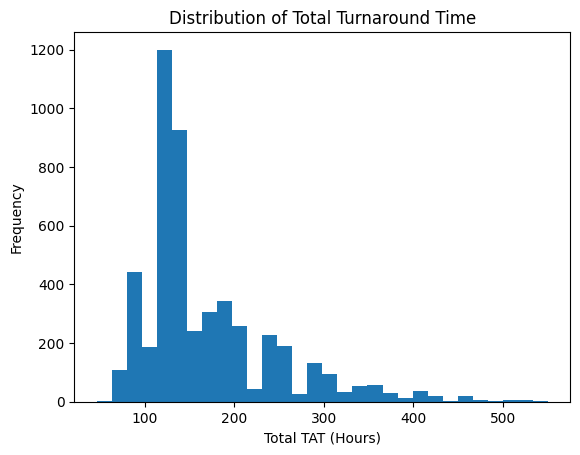

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(request_df["Total_TAT"], bins=30)
plt.title("Distribution of Total Turnaround Time")
plt.xlabel("Total TAT (Hours)")
plt.ylabel("Frequency")
plt.show()

### Request Type Analysis

In [10]:
request_df.groupby("Request_Type")["Total_TAT"].mean().sort_values(ascending=False)

Request_Type
Vendor Contract    185.473580
Equipment          175.720701
IT Purchase        163.312817
Office Supplies    150.071529
Name: Total_TAT, dtype: float64

### Priority Analysis

In [11]:
request_df.groupby("Priority")["Total_TAT"].mean().sort_values(ascending=False)

Priority
Low       190.116914
Medium    166.068502
High      148.657905
Name: Total_TAT, dtype: float64

### Department Analysis

In [12]:
request_df.groupby("Department_Requesting")["Total_TAT"].mean().sort_values(ascending=False)

Department_Requesting
IT            170.169268
Operations    170.075511
HR            169.629389
Finance       167.609840
Admin         165.541914
Name: Total_TAT, dtype: float64

### Vendor Type Analysis

In [13]:
request_df.groupby("Vendor_Type")["Total_TAT"].mean()

Vendor_Type
External    174.031130
Internal    163.203025
Name: Total_TAT, dtype: float64

### Delay Distribution

In [14]:
request_df["Delayed_Flag"].value_counts(normalize=True) * 100

Delayed_Flag
0    68.48
1    31.52
Name: proportion, dtype: float64

### Rework Frequency

In [15]:
stage_df["Rework_Flag"].value_counts(normalize=True) * 100

Rework_Flag
0    89.986654
1    10.013346
Name: proportion, dtype: float64

### Key Observations

- Turnaround time varies significantly across request types and complexity levels  
- High priority requests tend to have lower turnaround time due to faster processing  
- Certain departments show consistently higher turnaround times, indicating possible inefficiencies  
- External vendors may introduce additional delays compared to internal workflows  
- A significant proportion of requests exceed SLA, making delay prediction meaningful  
- Rework events contribute to extended processing times and workflow inefficiency  